In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import sys
from os import path, makedirs
from datetime import datetime
import pickle

# local imports
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config_new import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers_new import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
from matplotlib.patches import Patch

plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [3]:
show_plot = True


save_fig = True
save_fig_base_dir = "/exp/sbnd/data/users/munjung/xsec/PLOTS/cosmics"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"dent-{today_str}")
if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)


save_content = True
save_content_base_dir = "/exp/sbnd/data/users/munjung/xsec/RESULTS/cosmics"
save_content_dir = path.join(save_content_base_dir, f"dent-{today_str}")
if save_content:
    if not path.exists(save_content_dir):
        makedirs(save_content_dir)
    print("saving nevts in ", save_content_dir)

saving plots in  /exp/sbnd/data/users/munjung/xsec/PLOTS/cosmics/dent-20260506
saving nevts in  /exp/sbnd/data/users/munjung/xsec/RESULTS/cosmics/dent-20260506


In [4]:
# OffBeam
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight"
keys2load_offbeam = ['hdr', 'evt', 'trk']
df_offbeam = dfs_from_dir(search_dir=df_dir, filename_str="sel_all-data-OffBeamLight_10", keys2load=keys2load_offbeam, n_max_concat=999)

# Intime
df_dir = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime"
keys2load_intime = ['hdr', 'evt', 'trk']
df_intime = dfs_from_dir(search_dir=df_dir, filename_str="sel_all-mc-Intime_10", keys2load=keys2load_intime, n_max_concat=999)

Found 11 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_104.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight/sel_all-data-OffBeamLight_105.df', '/pnfs/sbnd/scratch/users/munjung/cafpy

100%|██████████| 11/11 [00:32<00:00,  2.93s/it]


Found 11 files to process
Files to process: ['/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_10.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_100.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_101.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_102.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_103.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_104.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_105.df', '/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime/sel_all-mc-Intime_106.df', '/pnfs/sbnd/scratch/users/munjung/ca

100%|██████████| 11/11 [00:26<00:00,  2.42s/it]


In [5]:
offbeam_hdr_df, offbeam_evt_df, offbeam_trk_df = df_offbeam["hdr"], df_offbeam["evt"], df_offbeam["trk"]
intime_hdr_df, intime_evt_df, intime_trk_df = df_intime["hdr"], df_intime["evt"], df_intime["trk"]

In [6]:
# -- Offbeam exposure scaling
offbeam_gates = offbeam_hdr_df.loc[offbeam_hdr_df['first_in_subrun'] == 1, 'noffbeambnb'].sum()
scale_offbeam_to_lightdata = offbeam_gates / offbeam_gates if offbeam_gates > 0 else 0
offbeam_evt_df["gates_weight"] = scale_offbeam_to_lightdata
offbeam_evt_df["pot_weight"] = scale_offbeam_to_lightdata
offbeam_trk_df["pot_weight"] = scale_offbeam_to_lightdata
print(f"offbeam cosmics data gates: {offbeam_gates:.2e}", f"goal scale: {scale_offbeam_to_lightdata:.2f}")

# -- Intime MC cosmics scaling
intime_gates = intime_hdr_df.loc[intime_hdr_df['first_in_subrun'] == 1, 'ngenevt'].sum()
scale_intime_to_lightdata = offbeam_gates / intime_gates if intime_gates > 0 else 0
intime_evt_df["gates_weight"] = scale_intime_to_lightdata
intime_evt_df["pot_weight"] = scale_intime_to_lightdata
intime_trk_df["pot_weight"] = scale_intime_to_lightdata
print(f"intime cosmics data gates: {intime_gates:.2e}", f"goal scale: {scale_intime_to_lightdata:.2f}")

offbeam cosmics data gates: 1.84e+06 goal scale: 1.00
intime cosmics data gates: 2.28e+06 goal scale: 0.81


In [7]:
pot_str = get_pot_str(offbeam_gates)
plot_labels_bar = ["Events (ngates={})".format(offbeam_gates), "", ""]
plot_labels_hist = ["", "Events (ngates={})".format(offbeam_gates), ""]

# Track Phi Investigation
Compare intime (MC cosmics) vs off-beam (data cosmics) track phi distributions.
Check primary, secondary, ... tracks per slice separately, and all tracks combined.

In [11]:
# --- Prepare track dataframes ---
offbeam_trk = get_valid_trks(offbeam_trk_df)
intime_trk  = get_valid_trks(intime_trk_df)

# inherit pot_weight from evt df by matching slice index
offbeam_trk = match_trkdf_to_slcdf(offbeam_trk, offbeam_evt_df)
intime_trk  = match_trkdf_to_slcdf(intime_trk,  intime_evt_df)

# compute phi (degrees) in the x-y plane from track direction
PHI_COL = ('pfp', 'trk', 'phi', '', '', '')
LEN_COL = ('pfp', 'trk', 'len', '', '', '')

for trk_df in (offbeam_trk, intime_trk):
    trk_df[PHI_COL] = np.degrees(
        np.arctan2(trk_df['pfp', 'trk', 'dir', 'x', ''],
                   trk_df['pfp', 'trk', 'dir', 'y', ''])
    )

print("offbeam tracks:", len(offbeam_trk))
print("intime  tracks:", len(intime_trk))

offbeam tracks: 1963773
intime  tracks: 2224461


In [12]:
# Sort tracks by length (longest first) within each slice to define rank
# index levels: [run, subrun, event, trkIdx]  -> group on first 3 levels
GRP_LEVELS = [0, 1, 2]
N_RANKS = 3   # primary, secondary, tertiary
RANK_LABELS = ["Longest", "2nd Longest", "3rd Longest"]

def ranked_trks(trk_df, n_ranks=N_RANKS):
    """Return list of per-rank track sub-dfs sorted by length descending."""
    sorted_df = trk_df.sort_values(LEN_COL, ascending=False)
    return [sorted_df.groupby(level=GRP_LEVELS).nth(i) for i in range(n_ranks)]

offbeam_ranked = ranked_trks(offbeam_trk)
intime_ranked  = ranked_trks(intime_trk)

print("Tracks per rank (offbeam / intime):")
for i, lbl in enumerate(RANK_LABELS):
    print(f"  {lbl}: {len(offbeam_ranked[i])} / {len(intime_ranked[i])}")

Tracks per rank (offbeam / intime):
  Longest: 341834 / 418757
  2nd Longest: 307233 / 377306
  3rd Longest: 236346 / 282794


In [13]:
# --- Track-level cuts ---
# Define cuts as a list of (label, mask_function) tuples.
# Each mask_function receives a track DataFrame and returns a boolean Series.
# Uncomment or add entries to activate cuts; leave CUTS empty to use all tracks.

DIR_X_COL = ('pfp', 'trk', 'dir', 'x', '', '')
DIR_Y_COL = ('pfp', 'trk', 'dir', 'y', '', '')
DIR_Z_COL = ('pfp', 'trk', 'dir', 'z', '', '')

CUTS = [
    ("len > 100 cm",        lambda df: df[LEN_COL] > 100),
    ("|dir.x| < 0.8",       lambda df: df[DIR_X_COL].abs() < 0.8),
    # ("|dir.y| < 0.8",       lambda df: df[DIR_Y_COL].abs() < 0.8),
    # ("|dir.z| < 0.8",       lambda df: df[DIR_Z_COL].abs() < 0.8),
]

def apply_cuts(df, cuts):
    """Return df filtered by all cuts in the list."""
    if not cuts:
        return df
    mask = pd.Series(True, index=df.index)
    for _lbl, mask_fn in cuts:
        mask &= mask_fn(df)
    return df[mask]

# Apply cuts -- overwrites working dfs so all downstream cells pick them up
_ob_raw_n = len(offbeam_trk)
_it_raw_n = len(intime_trk)

offbeam_trk     = apply_cuts(offbeam_trk, CUTS)
intime_trk      = apply_cuts(intime_trk,  CUTS)
offbeam_ranked  = [apply_cuts(r, CUTS) for r in offbeam_ranked]
intime_ranked   = [apply_cuts(r, CUTS) for r in intime_ranked]

cut_label = " & ".join(lbl for lbl, _ in CUTS) if CUTS else "none"
print(f"Cuts: {cut_label}")
print(f"offbeam tracks: {_ob_raw_n} -> {len(offbeam_trk)}  ({100*len(offbeam_trk)/_ob_raw_n:.1f}%)")
print(f"intime  tracks: {_it_raw_n} -> {len(intime_trk)}  ({100*len(intime_trk)/_it_raw_n:.1f}%)")

Cuts: len > 100 cm & |dir.x| < 0.8
offbeam tracks: 1963773 -> 234768  (12.0%)
intime  tracks: 2224461 -> 298414  (13.4%)


In [17]:
END_X_COL = ('pfp', 'trk', 'end', 'x', '', '')
END_Y_COL = ('pfp', 'trk', 'end', 'y', '', '')
END_Z_COL = ('pfp', 'trk', 'end', 'z', '', '')

saved: /exp/sbnd/data/users/munjung/xsec/PLOTS/cosmics/dent-20260506/trk_phi_per_rank.pdf


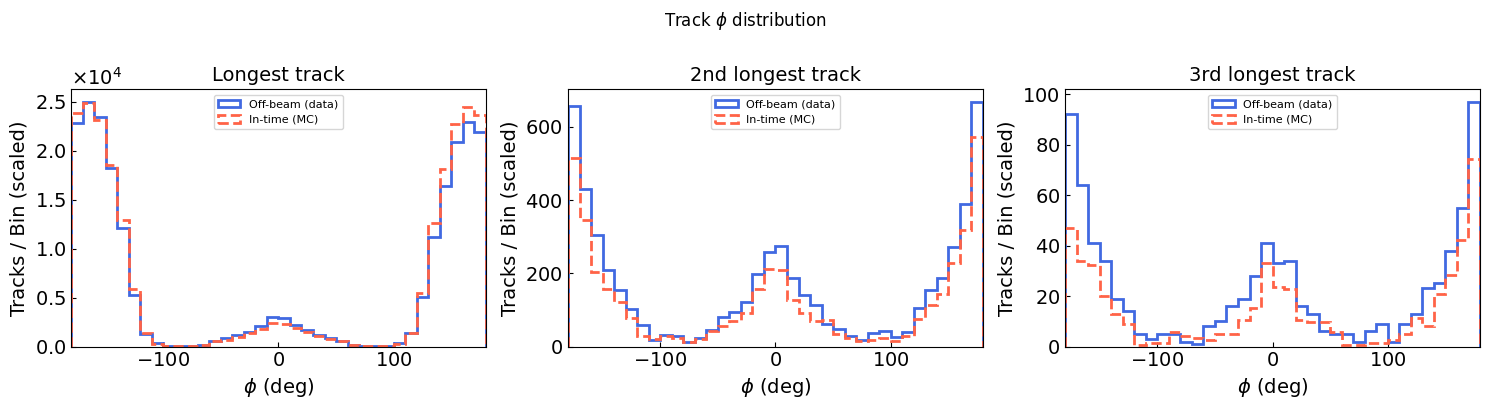

In [14]:
# --- phi distributions: primary / secondary / tertiary tracks per slice ---
phi_bins = np.linspace(-180, 180, 37)   # 10-deg bins

# pot_weight is a flat column set directly on the track dfs in the scaling cell
def get_wgts(df):
    """Return pot_weight column regardless of whether df has MultiIndex columns."""
    try:
        return df["pot_weight"]
    except KeyError:
        return df[("pot_weight", "", "", "", "", "")]

fig, axes = plt.subplots(1, N_RANKS, figsize=(5 * N_RANKS, 4), sharey=False)

for ax, lbl, ob_rank, it_rank in zip(
    axes, RANK_LABELS, offbeam_ranked, intime_ranked
):
    ax.hist(ob_rank[PHI_COL], bins=phi_bins, weights=get_wgts(ob_rank),
            histtype="step", color="royalblue", label="Off-beam (data)", linewidth=2)
    ax.hist(it_rank[PHI_COL], bins=phi_bins, weights=get_wgts(it_rank),
            histtype="step", color="tomato",  label="In-time (MC)",  linewidth=2, linestyle="--")

    ax.set_xlabel(r"$\phi$ (deg)")
    ax.set_ylabel("Tracks / Bin (scaled)")
    ax.set_title(f"{lbl.capitalize()} track")
    ax.set_xlim(-180, 180)
    ax.legend(fontsize=8)

fig.suptitle("Track $\\phi$ distribution", y=1.01)
fig.tight_layout()

if save_fig:
    save_name = path.join(save_fig_dir, "trk_phi_per_rank.pdf")
    fig.savefig(save_name, bbox_inches="tight")
    print("saved:", save_name)

if show_plot:
    plt.show()
else:
    plt.close()

saved: /exp/sbnd/data/users/munjung/xsec/PLOTS/cosmics/dent-20260506/trk_phi_all.pdf


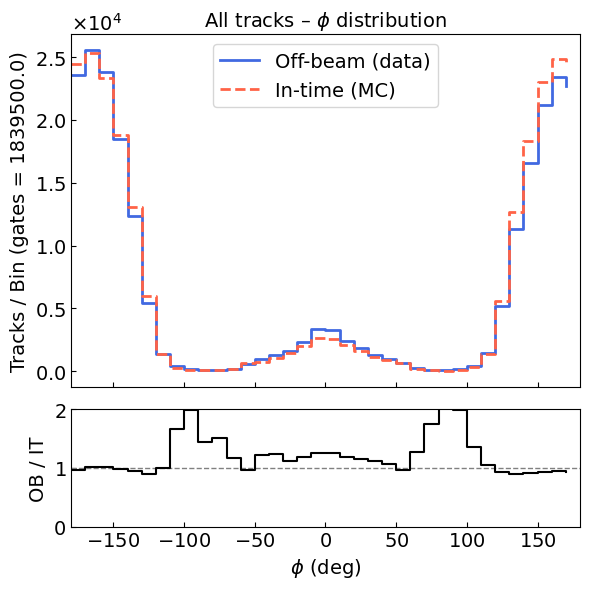

In [15]:
# --- phi distribution for ALL tracks combined ---
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(6, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True
)

h_ob, _ = np.histogram(offbeam_trk[PHI_COL], bins=phi_bins, weights=get_wgts(offbeam_trk))
h_it, _ = np.histogram(intime_trk[PHI_COL],  bins=phi_bins, weights=get_wgts(intime_trk))

ax_top.step(phi_bins[:-1], h_ob, where="post",
            color="royalblue", label="Off-beam (data)", linewidth=2)
ax_top.step(phi_bins[:-1], h_it, where="post",
            color="tomato",    label="In-time (MC)",    linewidth=2, linestyle="--")
ax_top.set_ylabel("Tracks / Bin (gates = {})".format(offbeam_gates))
ax_top.set_title("All tracks – $\\phi$ distribution")
ax_top.set_xlim(-180, 180)
ax_top.legend()

with np.errstate(divide="ignore", invalid="ignore"):
    ratio = np.where(h_it > 0, h_ob / h_it, np.nan)
ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
ax_bot.step(phi_bins[:-1], ratio, where="post", color="black", linewidth=1.5)
ax_bot.set_xlabel(r"$\phi$ (deg)")
ax_bot.set_ylabel("OB / IT")
ax_bot.set_xlim(-180, 180)
ax_bot.set_ylim(0, 2)

fig.tight_layout()

if save_fig:
    save_name = path.join(save_fig_dir, "trk_phi_all.pdf")
    fig.savefig(save_name, bbox_inches="tight")
    print("saved:", save_name)

if show_plot:
    plt.show()
else:
    plt.close()

saved: /exp/sbnd/data/users/munjung/xsec/PLOTS/cosmics/dent-20260506/trk_phi_ratio.pdf


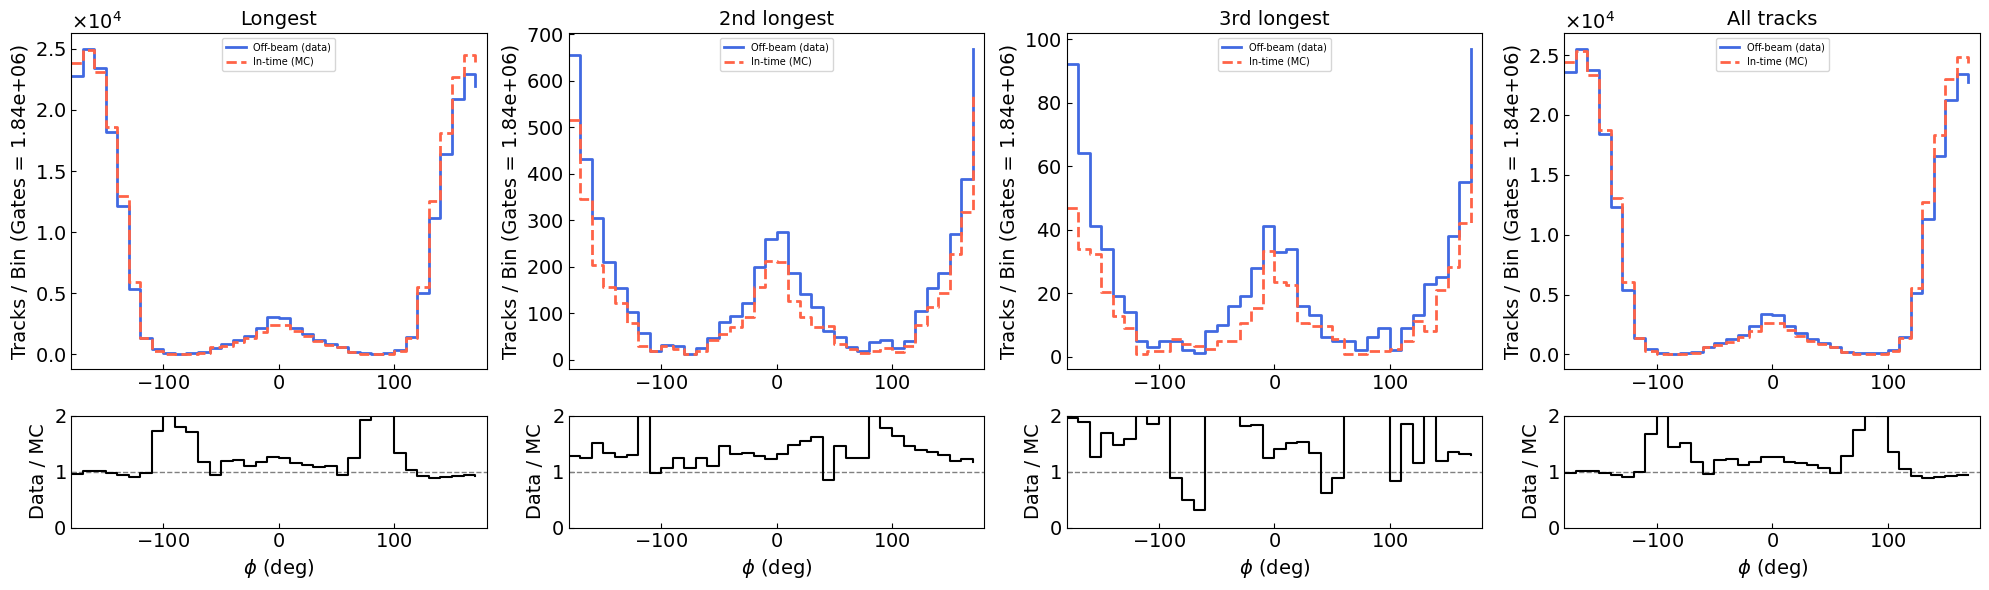

In [16]:
# --- ratio plots: off-beam / in-time for each rank + all tracks ---
rank_sets = list(zip(RANK_LABELS, offbeam_ranked, intime_ranked)) + \
            [("all tracks", offbeam_trk, intime_trk)]

n_panels = len(rank_sets)
fig, axes = plt.subplots(2, n_panels, figsize=(5 * n_panels, 6),
                         gridspec_kw={"height_ratios": [3, 1]})

for col, (lbl, ob_df, it_df) in enumerate(rank_sets):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    h_ob, _ = np.histogram(ob_df[PHI_COL], bins=phi_bins, weights=get_wgts(ob_df))
    h_it, _ = np.histogram(it_df[PHI_COL], bins=phi_bins, weights=get_wgts(it_df))

    ax_top.step(phi_bins[:-1], h_ob, where="post",
                color="royalblue", label="Off-beam (data)", linewidth=2)
    ax_top.step(phi_bins[:-1], h_it, where="post",
                color="tomato",    label="In-time (MC)",  linewidth=2, linestyle="--")
    ax_top.set_ylabel("Tracks / Bin (Gates = {:.2e})".format(offbeam_gates))
    ax_top.set_title(lbl.capitalize())
    ax_top.set_xlim(-180, 180)
    ax_top.legend(fontsize=7)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(h_it > 0, h_ob / h_it, np.nan)
    ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax_bot.step(phi_bins[:-1], ratio, where="post", color="black", linewidth=1.5)
    ax_bot.set_xlabel(r"$\phi$ (deg)")
    ax_bot.set_ylabel("Data / MC")
    ax_bot.set_xlim(-180, 180)
    ax_bot.set_ylim(0, 2)

# fig.suptitle("Track $\\phi$: Off-beam vs In-time (ratio = OB/IT)", y=1.01)
fig.tight_layout()

if save_fig:
    save_name = path.join(save_fig_dir, "trk_phi_ratio.pdf")
    fig.savefig(save_name, bbox_inches="tight")
    print("saved:", save_name)

if show_plot:
    plt.show()
else:
    plt.close()

saved: /exp/sbnd/data/users/munjung/xsec/PLOTS/cosmics/dent-20260506/trk_phi_ratio.pdf


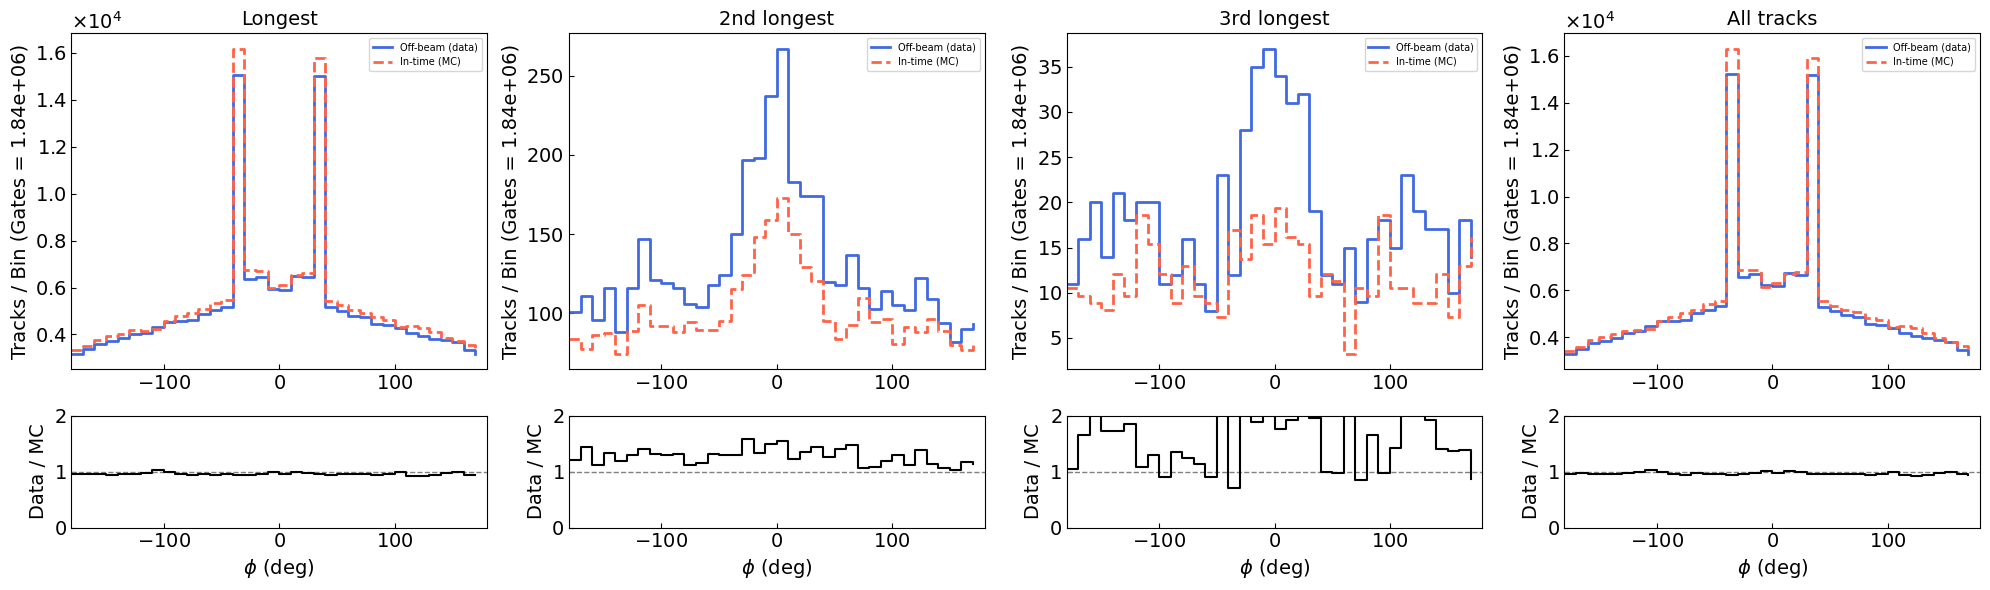

In [18]:
# --- ratio plots: off-beam / in-time for each rank + all tracks ---
rank_sets = list(zip(RANK_LABELS, offbeam_ranked, intime_ranked)) + \
            [("all tracks", offbeam_trk, intime_trk)]

n_panels = len(rank_sets)
fig, axes = plt.subplots(2, n_panels, figsize=(5 * n_panels, 6),
                         gridspec_kw={"height_ratios": [3, 1]})

for col, (lbl, ob_df, it_df) in enumerate(rank_sets):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    h_ob, _ = np.histogram(ob_df[END_X_COL], bins=phi_bins, weights=get_wgts(ob_df))
    h_it, _ = np.histogram(it_df[END_X_COL], bins=phi_bins, weights=get_wgts(it_df))

    ax_top.step(phi_bins[:-1], h_ob, where="post",
                color="royalblue", label="Off-beam (data)", linewidth=2)
    ax_top.step(phi_bins[:-1], h_it, where="post",
                color="tomato",    label="In-time (MC)",  linewidth=2, linestyle="--")
    ax_top.set_ylabel("Tracks / Bin (Gates = {:.2e})".format(offbeam_gates))
    ax_top.set_title(lbl.capitalize())
    ax_top.set_xlim(-180, 180)
    ax_top.legend(fontsize=7)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(h_it > 0, h_ob / h_it, np.nan)
    ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax_bot.step(phi_bins[:-1], ratio, where="post", color="black", linewidth=1.5)
    ax_bot.set_xlabel(r"$\phi$ (deg)")
    ax_bot.set_ylabel("Data / MC")
    ax_bot.set_xlim(-180, 180)
    ax_bot.set_ylim(0, 2)

# fig.suptitle("Track $\\phi$: Off-beam vs In-time (ratio = OB/IT)", y=1.01)
fig.tight_layout()

if save_fig:
    save_name = path.join(save_fig_dir, "trk_phi_ratio.pdf")
    fig.savefig(save_name, bbox_inches="tight")
    print("saved:", save_name)

if show_plot:
    plt.show()
else:
    plt.close()

In [ ]:
# --- Variable configs for additional distribution plots ---
# Each entry: (col_tuple, bins, x_label, save_name_stem)
VAR_CONFIGS = [
    (
        ('pfp', 'trk', 'dir', 'x', '', ''),
        np.linspace(-1, 1, 41),
        r"$\hat{x}$ (dir.x)",
        "trk_dir_x",
    ),
    (
        ('pfp', 'trk', 'dir', 'y', '', ''),
        np.linspace(-1, 1, 41),
        r"$\hat{y}$ (dir.y)",
        "trk_dir_y",
    ),
    (
        ('pfp', 'trk', 'dir', 'z', '', ''),
        np.linspace(-1, 1, 41),
        r"$\hat{z}$ (dir.z)",
        "trk_dir_z",
    ),
    (
        LEN_COL,
        np.linspace(0, 500, 51),
        "Track length (cm)",
        "trk_len",
    ),
]

In [ ]:
# --- Per-rank + all-tracks distribution plots for dir.x/y/z and len ---
def make_dist_plots(col, bins, xlabel, save_stem):
    """
    Make two figures for a given track variable:
      1. Per-rank (N_RANKS columns), each with distribution + OB/IT ratio panel.
      2. All tracks combined, same layout.
    """
    # ---- per-rank figure ----
    fig, axes = plt.subplots(
        2, N_RANKS, figsize=(5 * N_RANKS, 7),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )
    for c, (lbl, ob_rank, it_rank) in enumerate(
        zip(RANK_LABELS, offbeam_ranked, intime_ranked)
    ):
        ax_top = axes[0, c]
        ax_bot = axes[1, c]

        h_ob, _ = np.histogram(ob_rank[col], bins=bins, weights=get_wgts(ob_rank))
        h_it, _ = np.histogram(it_rank[col], bins=bins, weights=get_wgts(it_rank))

        ax_top.step(bins[:-1], h_ob, where="post",
                    color="royalblue", label="Off-beam (data)", linewidth=2)
        ax_top.step(bins[:-1], h_it, where="post",
                    color="tomato",    label="In-time (MC)",    linewidth=2, linestyle="--")
        ax_top.set_ylabel("Tracks / Bin (scaled)")
        ax_top.set_title(f"{lbl.capitalize()} track")
        ax_top.set_xlim(bins[0], bins[-1])
        ax_top.legend(fontsize=8)

        with np.errstate(divide="ignore", invalid="ignore"):
            ratio = np.where(h_it > 0, h_ob / h_it, np.nan)
        ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
        ax_bot.step(bins[:-1], ratio, where="post", color="black", linewidth=1.5)
        ax_bot.set_xlabel(xlabel)
        ax_bot.set_ylabel("OB / IT")
        ax_bot.set_xlim(bins[0], bins[-1])
        ax_bot.set_ylim(0, 2)

    fig.suptitle(f"Track {xlabel} distribution", y=1.01)
    fig.tight_layout()
    if save_fig:
        save_name = path.join(save_fig_dir, f"{save_stem}_per_rank.pdf")
        fig.savefig(save_name, bbox_inches="tight")
        print("saved:", save_name)
    if show_plot:
        plt.show()
    else:
        plt.close()

    # ---- all-tracks figure ----
    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(6, 6),
        gridspec_kw={"height_ratios": [3, 1]},
        sharex=True,
    )
    h_ob, _ = np.histogram(offbeam_trk[col], bins=bins, weights=get_wgts(offbeam_trk))
    h_it, _ = np.histogram(intime_trk[col],  bins=bins, weights=get_wgts(intime_trk))

    ax_top.step(bins[:-1], h_ob, where="post",
                color="royalblue", label="Off-beam (data)", linewidth=2)
    ax_top.step(bins[:-1], h_it, where="post",
                color="tomato",    label="In-time (MC)",    linewidth=2, linestyle="--")
    ax_top.set_ylabel("Tracks / Bin (scaled)")
    ax_top.set_title(f"All tracks – {xlabel} distribution")
    ax_top.set_xlim(bins[0], bins[-1])
    ax_top.legend()

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(h_it > 0, h_ob / h_it, np.nan)
    ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax_bot.step(bins[:-1], ratio, where="post", color="black", linewidth=1.5)
    ax_bot.set_xlabel(xlabel)
    ax_bot.set_ylabel("OB / IT")
    ax_bot.set_xlim(bins[0], bins[-1])
    ax_bot.set_ylim(0, 2)

    fig.tight_layout()
    if save_fig:
        save_name = path.join(save_fig_dir, f"{save_stem}_all.pdf")
        fig.savefig(save_name, bbox_inches="tight")
        print("saved:", save_name)
    if show_plot:
        plt.show()
    else:
        plt.close()


for col, bins, xlabel, save_stem in VAR_CONFIGS:
    make_dist_plots(col, bins, xlabel, save_stem)

# Detector Investigation: phi ≈ 90 Discrepancy & dir.x Asymmetry

**Hypotheses:**
1. **phi ≈ 90 dip** — tracks going along the drift (x) direction have highly degenerate wire projections on the collection plane. Any dead/noisy wires in that angular region suppress data tracks but not MC (which has perfect wire efficiency by default).
2. **dir.x asymmetry** — TPC 0 (x < 0) and TPC 1 (x > 0) have independent wire readout. Different numbers of dead channels or gain miscalibration on one side creates a left–right asymmetry for data cosmics, which should be symmetric by isotropy.

**Investigation plan:**
1. Load hit dataframes (plane 0 = U, plane 1 = V, plane 2 = Y/collection)
2. Wire occupancy per plane — dead-wire regions appear as dips in data but not MC
3. TPC-split track rates — isolate which TPC drives the dir.x asymmetry
4. Mean nhits-per-track vs phi — fewer hits in data at phi ≈ 90 confirms wire-efficiency origin

In [ ]:
# --- Load hit dataframes (one per wire plane) ---
# hit0 = U plane (induction), hit1 = V plane (induction), hit2 = Y plane (collection)
# Columns per hit: dedx, dqdx, pitch, integral, rr, phi, efield, wire, tpc,
#                  sumadc, t, x, y, z, firsthit, lasthit, cryo, plane

df_dir_offbeam = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_04_140839__sel_all-data-OffBeamLight"
df_dir_intime  = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_03_113509__sel_all-mc-Intime"

df_offbeam_hits = dfs_from_dir(
    search_dir=df_dir_offbeam,
    filename_str="sel_all-data-OffBeamLight_10",
    keys2load=["hit0", "hit1", "hit2"],
    n_max_concat=999,
)
df_intime_hits = dfs_from_dir(
    search_dir=df_dir_intime,
    filename_str="sel_all-mc-Intime_10",
    keys2load=["hit0", "hit1", "hit2"],
    n_max_concat=999,
)

ob_hit = {i: df_offbeam_hits[f"hit{i}"] for i in range(3)}
it_hit = {i: df_intime_hits[f"hit{i}"]  for i in range(3)}

# propagate pot_weight to hit dfs (flat scale, same as trk dfs)
for i in range(3):
    ob_hit[i]["pot_weight"] = scale_offbeam_to_lightdata
    it_hit[i]["pot_weight"] = scale_intime_to_lightdata

print("Hit counts loaded (offbeam / intime):")
for i in range(3):
    print(f"  Plane {i}: {len(ob_hit[i]):,} / {len(it_hit[i]):,}")

In [ ]:
# --- Investigation 1: Wire occupancy per plane ---
# Dead wire regions show as dips in data but not MC.
# Plot wire number distributions for all three planes, split by TPC.
# SBND: TPC 0 => tpc==0, TPC 1 => tpc==1 (within each plane)

PLANE_LABELS = ["U (plane 0, induction)", "V (plane 1, induction)", "Y (plane 2, collection)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8), gridspec_kw={"height_ratios": [3, 1]},
                         sharex="col")

for col, (plane, label) in enumerate(zip(range(3), PLANE_LABELS)):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ob_df = ob_hit[plane]
    it_df = it_hit[plane]

    # use wire range as bins
    wire_min = int(min(ob_df.wire.min(), it_df.wire.min()))
    wire_max = int(max(ob_df.wire.max(), it_df.wire.max()))
    wire_bins = np.arange(wire_min, wire_max + 2, 4)   # 4-wire bins

    h_ob, _ = np.histogram(ob_df.wire, bins=wire_bins,
                           weights=ob_df.pot_weight)
    h_it, _ = np.histogram(it_df.wire, bins=wire_bins,
                           weights=it_df.pot_weight)

    ax_top.step(wire_bins[:-1], h_ob, where="post",
                color="royalblue", label="Off-beam (data)", linewidth=1.5)
    ax_top.step(wire_bins[:-1], h_it, where="post",
                color="tomato",    label="In-time (MC)",    linewidth=1.5, linestyle="--")
    ax_top.set_ylabel("Hits / 4 wires (scaled)")
    ax_top.set_title(label)
    ax_top.legend(fontsize=8)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(h_it > 0, h_ob / h_it, np.nan)
    ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax_bot.step(wire_bins[:-1], ratio, where="post", color="black", linewidth=1.2)
    ax_bot.set_xlabel("Wire number")
    ax_bot.set_ylabel("OB / IT")
    ax_bot.set_ylim(0, 2)

fig.suptitle("Wire occupancy per plane — dips in ratio indicate dead/noisy wires in data",
             y=1.01)
fig.tight_layout()

if save_fig:
    save_name = path.join(save_fig_dir, "wire_occupancy_per_plane.pdf")
    fig.savefig(save_name, bbox_inches="tight")
    print("saved:", save_name)
if show_plot:
    plt.show()
else:
    plt.close()

In [ ]:
# --- Investigation 2: TPC-split track rates ---
# Split tracks by which TPC they predominantly live in, using the majority TPC
# from collection-plane (plane 2) hits.  An imbalance in OB/IT ratio between
# TPC 0 and TPC 1 points to single-TPC hardware issues driving the dir.x asymmetry.

def majority_tpc(hit_df):
    """Return majority TPC label (0 or 1) per track from hit-level tpc column."""
    return (
        hit_df.groupby(level=list(range(hit_df.index.nlevels - 1)))["tpc"]
        .agg(lambda s: s.mode().iloc[0])
        .rename("majority_tpc")
    )

ob_tpc = majority_tpc(ob_hit[2])   # use collection plane
it_tpc = majority_tpc(it_hit[2])

# Build per-TPC boolean masks aligned to the track dfs — avoids joining a plain
# Series onto a MultiIndex-column DataFrame, which triggers a MergeError.
ob_in_tpc = {t: offbeam_trk.index.isin(ob_tpc[ob_tpc == t].index) for t in [0, 1]}
it_in_tpc = {t: intime_trk.index.isin(it_tpc[it_tpc == t].index)  for t in [0, 1]}

# --- dir.x split by TPC ---
fig, axes = plt.subplots(2, 2, figsize=(12, 7),
                         gridspec_kw={"height_ratios": [3, 1]},
                         sharex=True)
dirx_bins = np.linspace(-1, 1, 41)

for col, tpc_id in enumerate([0, 1]):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ob_sel = offbeam_trk[ob_in_tpc[tpc_id]]
    it_sel = intime_trk[it_in_tpc[tpc_id]]

    h_ob, _ = np.histogram(ob_sel[DIR_X_COL], bins=dirx_bins, weights=get_wgts(ob_sel))
    h_it, _ = np.histogram(it_sel[DIR_X_COL], bins=dirx_bins, weights=get_wgts(it_sel))

    ax_top.step(dirx_bins[:-1], h_ob, where="post",
                color="royalblue", label="Off-beam (data)", linewidth=2)
    ax_top.step(dirx_bins[:-1], h_it, where="post",
                color="tomato",    label="In-time (MC)",    linewidth=2, linestyle="--")
    ax_top.set_ylabel("Tracks / Bin (scaled)")
    ax_top.set_title(f"TPC {tpc_id}")
    ax_top.set_xlim(-1, 1)
    ax_top.legend(fontsize=8)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(h_it > 0, h_ob / h_it, np.nan)
    ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax_bot.step(dirx_bins[:-1], ratio, where="post", color="black", linewidth=1.5)
    ax_bot.set_xlabel(r"$\hat{x}$ (dir.x)")
    ax_bot.set_ylabel("OB / IT")
    ax_bot.set_xlim(-1, 1)
    ax_bot.set_ylim(0, 2)

fig.suptitle(r"dir.x split by TPC — asymmetry localized to one TPC $\Rightarrow$ single-TPC hardware issue",
             y=1.01)
fig.tight_layout()

if save_fig:
    save_name = path.join(save_fig_dir, "dirx_per_tpc.pdf")
    fig.savefig(save_name, bbox_inches="tight")
    print("saved:", save_name)
if show_plot:
    plt.show()
else:
    plt.close()

# Summary numbers
print("\nTrack counts by TPC (offbeam / intime):")
for tpc_id in [0, 1]:
    n_ob = ob_in_tpc[tpc_id].sum()
    n_it = it_in_tpc[tpc_id].sum()
    print(f"  TPC {tpc_id}: {n_ob:,} / {n_it:,}  ratio = {n_ob/n_it:.3f}")

In [ ]:
# --- Investigation 3: Mean nhits-per-track vs phi ---
# If fewer hits are found in data for tracks at phi≈90, the discrepancy is
# a hit-finding / wire-efficiency issue, not a track-finding one.
# We use collection-plane (plane 2) hits — most sensitive to track direction.

def nhits_per_track(hit_df):
    """Count hits per track from hit df index."""
    return hit_df.groupby(level=list(range(hit_df.index.nlevels - 1))).size().rename("nhits")

ob_nhits2 = nhits_per_track(ob_hit[2])
it_nhits2 = nhits_per_track(it_hit[2])

# reindex aligns the nhits Series to the (possibly cut) track df index without
# needing to join onto a MultiIndex-column DataFrame, which would raise MergeError.
ob_nhits_arr = ob_nhits2.reindex(offbeam_trk.index).to_numpy(dtype=float)
it_nhits_arr = it_nhits2.reindex(intime_trk.index).to_numpy(dtype=float)

# Bin tracks by phi and compute weighted mean nhits in each bin
def weighted_mean_nhits(trk_df, nhits_arr, phi_bins):
    phi_vals = trk_df[PHI_COL].values
    wgt_vals = get_wgts(trk_df).values
    means = np.full(len(phi_bins) - 1, np.nan)
    for k in range(len(phi_bins) - 1):
        mask = (phi_vals >= phi_bins[k]) & (phi_vals < phi_bins[k + 1])
        w = wgt_vals[mask]
        n = nhits_arr[mask]
        valid = np.isfinite(n)
        if w[valid].sum() > 0:
            means[k] = np.average(n[valid], weights=w[valid])
    return means

mean_ob = weighted_mean_nhits(offbeam_trk, ob_nhits_arr, phi_bins)
mean_it = weighted_mean_nhits(intime_trk,  it_nhits_arr, phi_bins)

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(7, 6),
    gridspec_kw={"height_ratios": [3, 1]},
    sharex=True,
)

ax_top.step(phi_bins[:-1], mean_ob, where="post",
            color="royalblue", label="Off-beam (data)", linewidth=2)
ax_top.step(phi_bins[:-1], mean_it, where="post",
            color="tomato",    label="In-time (MC)",    linewidth=2, linestyle="--")
ax_top.set_ylabel("Mean $N_\\mathrm{hits}$ per track (plane 2)")
ax_top.set_title(r"Mean collection-plane hits vs track $\phi$")
ax_top.set_xlim(-180, 180)
ax_top.legend()

with np.errstate(divide="ignore", invalid="ignore"):
    ratio_nh = np.where(mean_it > 0, mean_ob / mean_it, np.nan)
ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
ax_bot.step(phi_bins[:-1], ratio_nh, where="post", color="black", linewidth=1.5)
ax_bot.set_xlabel(r"$\phi$ (deg)")
ax_bot.set_ylabel("OB / IT")
ax_bot.set_xlim(-180, 180)
ax_bot.set_ylim(0, 2)

fig.tight_layout()

if save_fig:
    save_name = path.join(save_fig_dir, "nhits_vs_phi.pdf")
    fig.savefig(save_name, bbox_inches="tight")
    print("saved:", save_name)
if show_plot:
    plt.show()
else:
    plt.close()

In [ ]:
# --- Investigation 4: Wire occupancy split by TPC ---
# Check whether dead-wire regions are confined to one TPC.
# SBND TPC 0 (tpc==0) and TPC 1 (tpc==1) have separate wire readout boards.
# A dead region in only one TPC would explain the dir.x asymmetry.

PLANE_LABELS_SHORT = ["U (plane 0)", "V (plane 1)", "Y (plane 2, collection)"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8),
                         gridspec_kw={"height_ratios": [3, 1]},
                         sharex="col")

for col, plane in enumerate(range(3)):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]

    ob_df = ob_hit[plane]
    it_df = it_hit[plane]

    wire_min = int(min(ob_df.wire.min(), it_df.wire.min()))
    wire_max = int(max(ob_df.wire.max(), it_df.wire.max()))
    wire_bins = np.arange(wire_min, wire_max + 2, 4)

    colors_ob = {0: "royalblue",   1: "cornflowerblue"}
    colors_it = {0: "tomato",      1: "lightsalmon"}
    ls_tpc    = {0: "-",           1: "--"}

    h_ob_all = np.zeros(len(wire_bins) - 1)
    h_it_all = np.zeros(len(wire_bins) - 1)

    for tpc_id in [0, 1]:
        ob_t = ob_df[ob_df.tpc == tpc_id]
        it_t = it_df[it_df.tpc == tpc_id]

        h_ob, _ = np.histogram(ob_t.wire, bins=wire_bins, weights=ob_t.pot_weight)
        h_it, _ = np.histogram(it_t.wire, bins=wire_bins, weights=it_t.pot_weight)

        ax_top.step(wire_bins[:-1], h_ob, where="post",
                    color=colors_ob[tpc_id], linestyle=ls_tpc[tpc_id],
                    label=f"OB TPC{tpc_id}", linewidth=1.5)
        ax_top.step(wire_bins[:-1], h_it, where="post",
                    color=colors_it[tpc_id], linestyle=ls_tpc[tpc_id],
                    label=f"IT TPC{tpc_id}", linewidth=1.5)

        h_ob_all += h_ob
        h_it_all += h_it

    ax_top.set_ylabel("Hits / 4 wires (scaled)")
    ax_top.set_title(PLANE_LABELS_SHORT[col])
    ax_top.legend(fontsize=7, ncol=2)

    with np.errstate(divide="ignore", invalid="ignore"):
        ratio = np.where(h_it_all > 0, h_ob_all / h_it_all, np.nan)
    ax_bot.axhline(1, color="gray", linestyle="--", linewidth=1)
    ax_bot.step(wire_bins[:-1], ratio, where="post", color="black", linewidth=1.2)
    ax_bot.set_xlabel("Wire number")
    ax_bot.set_ylabel("OB / IT (all TPCs)")
    ax_bot.set_ylim(0, 2)

fig.suptitle("Wire occupancy per plane, split by TPC — asymmetric dips $\\Rightarrow$ TPC-specific dead regions",
             y=1.01)
fig.tight_layout()

if save_fig:
    save_name = path.join(save_fig_dir, "wire_occupancy_per_tpc.pdf")
    fig.savefig(save_name, bbox_inches="tight")
    print("saved:", save_name)
if show_plot:
    plt.show()
else:
    plt.close()